# ML Lab 3 Decision Trees

Yasir Ahmad 22MIA1064

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
paths = []
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))
print(*paths,sep='\n')
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/drugs-a-b-c-x-y-for-decision-trees/drug200.csv


In [2]:
!pip install pydotplus

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.7/278.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24552 sha256=86bcbb5babe23806a0590d842ea456a812423df9888919103c5fb729ad9be818
  Stored in directory: /root/.cache/pip/wheels/69/b2/67/08f0eef649af92df772c09f451558298e07fab1bc7cdf33db0
Successfully built pydotplus


In [3]:
import pandas as pd
import numpy as np
import six
import sys
sys.modules['sklearn.externals.six'] = six

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from sklearn.externals.six import StringIO

from IPython.display import Image
import pydotplus


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import tree

## Preprocessing

In [5]:
df = pd.read_csv(paths[0])
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [6]:
df.shape

(200, 6)

In [7]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [8]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [9]:
df["Sex"].unique()

array(['F', 'M'], dtype=object)

In [10]:
df["Sex"] = df["Sex"].map({"M":0, "F":1})

In [11]:
df["BP"].unique()

array(['HIGH', 'LOW', 'NORMAL'], dtype=object)

In [12]:
df["BP"] = df["BP"].map({"LOW":0, "NORMAL":1, "HIGH":2})

In [13]:
df["Cholesterol"].unique()

array(['HIGH', 'NORMAL'], dtype=object)

In [14]:
df["Cholesterol"] = df["Cholesterol"].map({"NORMAL":0,"HIGH":1})

In [15]:
df["Drug"].unique()

array(['drugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

In [16]:
y_map = {'drugY':0, 'drugC':1, 'drugX':2, 'drugA':3, 'drugB':4}
inv_y_map = {0:'drugY', 1:'drugC', 2:'drugX', 3:'drugA', 4:'drugB'}

In [17]:
df["Drug"] = df["Drug"].map(y_map)

In [18]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,2,1,25.355,0
1,47,0,0,1,13.093,1
2,47,0,0,1,10.114,1
3,28,1,1,1,7.798,2
4,61,1,0,1,18.043,0


In [19]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [20]:
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']]
y = df["Drug"]

In [21]:
features = X.columns

In [22]:
features

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'], dtype='object')

# Decision Trees

## ID3

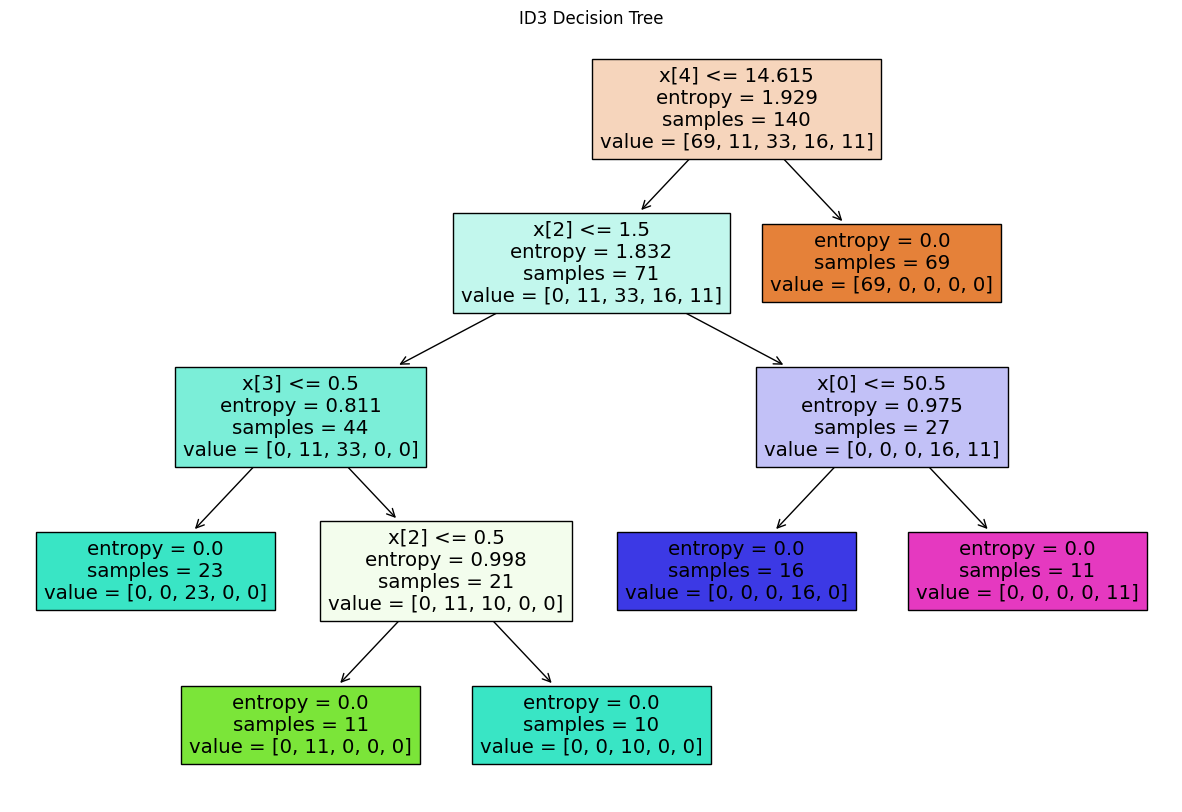

Accuracy before pruning: 0.9833333333333333


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


# Separating Training and Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=3)

# Train decision tree model
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)

# Plot original tree
plt.figure(figsize=(15, 10))
plot_tree(model, filled=True)
plt.title("ID3 Decision Tree")
plt.show()

# Model Accuracy before pruning
accuracy_before_pruning = model.score(X_test, y_test)
print("Accuracy before pruning:", accuracy_before_pruning)

## CART

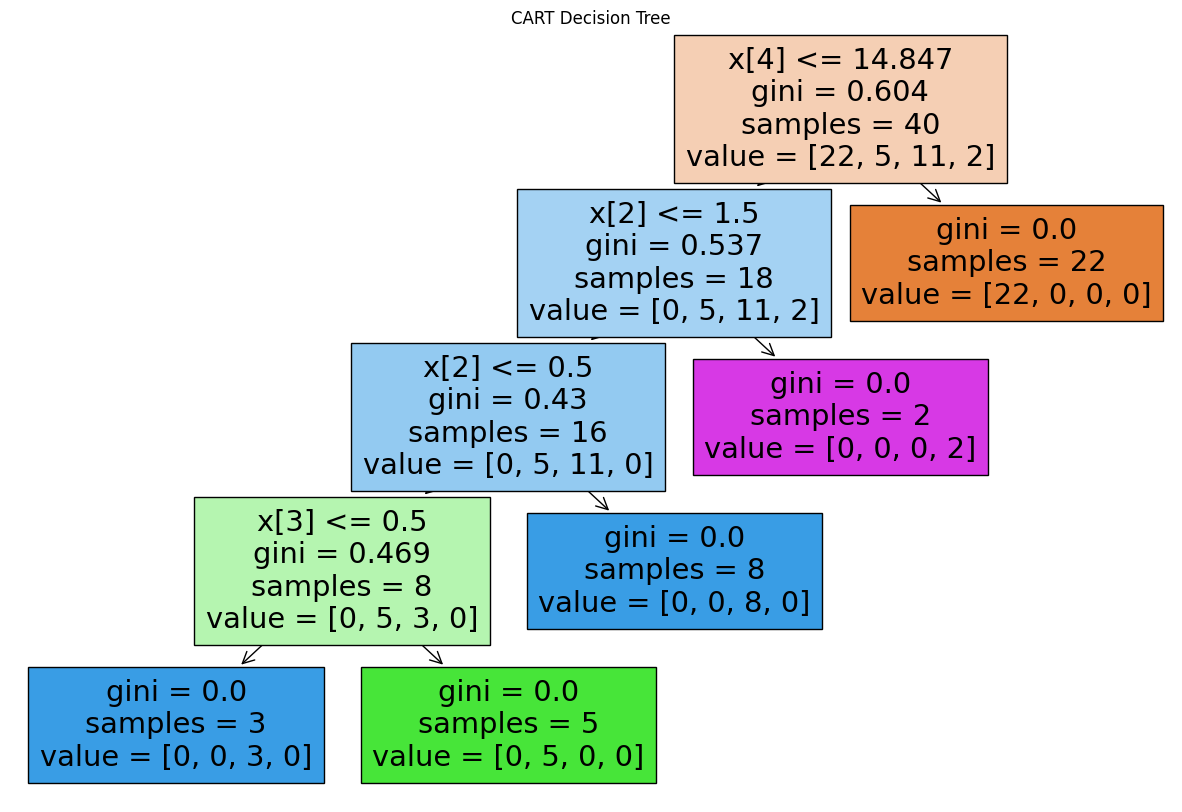

Accuracy before pruning: 0.85625


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


# Separating Training and Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)

# Train decision tree model
model = DecisionTreeClassifier(criterion="gini")
model.fit(X_train, y_train)

# Plot original tree
plt.figure(figsize=(15, 10))
plot_tree(model, filled=True)
plt.title("CART Decision Tree")
plt.show()

# Model Accuracy before pruning
accuracy_before_pruning = model.score(X_test, y_test)
print("Accuracy before pruning:", accuracy_before_pruning)

### Pruning

In [25]:
from sklearn.tree import DecisionTreeClassifier
parameter = {
    'criterion' :['entropy','gini','log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}
model = DecisionTreeClassifier()
from sklearn.model_selection import GridSearchCV
cv = GridSearchCV(model,param_grid = parameter,cv = 5)
cv.fit(X_train,y_train)


/opt/conda/lib/python3.10/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/tree/_classes.py:269: Futu

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']})

In [26]:
y.unique()

array([0, 1, 2, 3, 4])

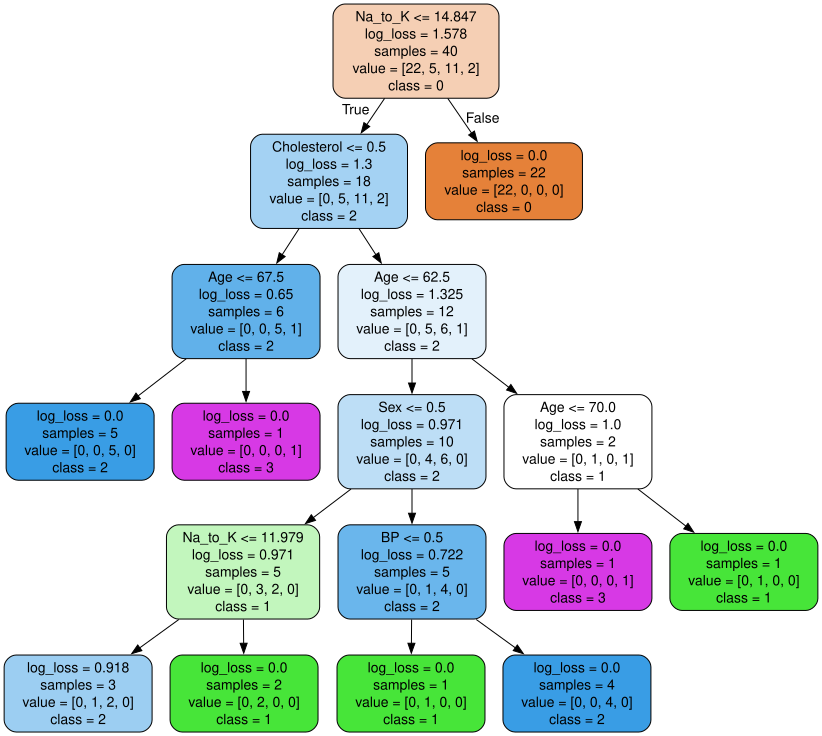

In [27]:
from sklearn.tree import export_graphviz
import graphviz
best_estimator = cv.best_estimator_
feature_names = features

dot_data = export_graphviz(best_estimator, out_file=None, filled=True, rounded=True,
feature_names=feature_names, class_names=['0','1','2','3','4'])
graph = graphviz.Source(dot_data)
graph.render("decision_tree", format='png', cleanup=True)
graph


In [28]:
cv.score(X_test,y_test)
cv.best_params_


{'criterion': 'log_loss',
 'max_depth': 5,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [29]:
cv.score(X_test,y_test)

0.7125

In [30]:
# Cost-complexity pruning (Post-pruning)
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Train a series of decision trees with different alpha values
pruned_models = []
for ccp_alpha in ccp_alphas:
    pruned_model = DecisionTreeClassifier(criterion="gini", ccp_alpha=ccp_alpha)
    pruned_model.fit(X_train, y_train)
    pruned_models.append(pruned_model)

# Find the model with the best accuracy on test data
best_accuracy = 0
best_pruned_model = None
for pruned_model in pruned_models:
    accuracy = pruned_model.score(X_test, y_test)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_pruned_model = pruned_model
# Model Accuracy after pruning
accuracy_after_pruning = best_pruned_model.score(X_test, y_test)
print("Accuracy after pruning:", accuracy_after_pruning)


Accuracy after pruning: 0.85625


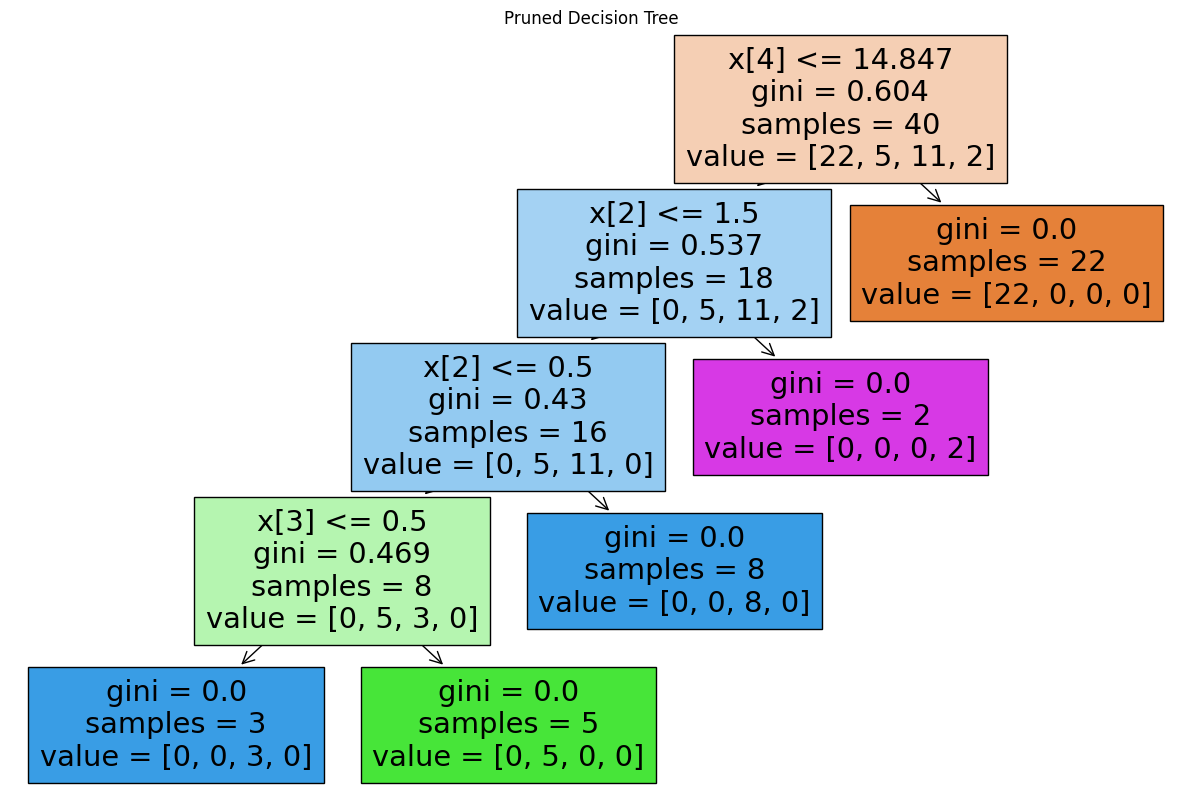

In [31]:
# Plot pruned tree
plt.figure(figsize=(15, 10))
plot_tree(best_pruned_model, filled=True)
plt.title("Pruned Decision Tree")
plt.show()


In [32]:
print("Best pruned model accuracy:", accuracy_after_pruning)

Best pruned model accuracy: 0.85625


### Adjusting threshold

In [33]:
tree2 = best_pruned_model
tree2.tree_.threshold

array([14.84699965,  1.5       ,  0.5       ,  0.5       , -2.        ,
       -2.        , -2.        , -2.        , -2.        ])

#### Changing the threshold at root node

In [34]:
tree2.tree_.threshold[0] = 12

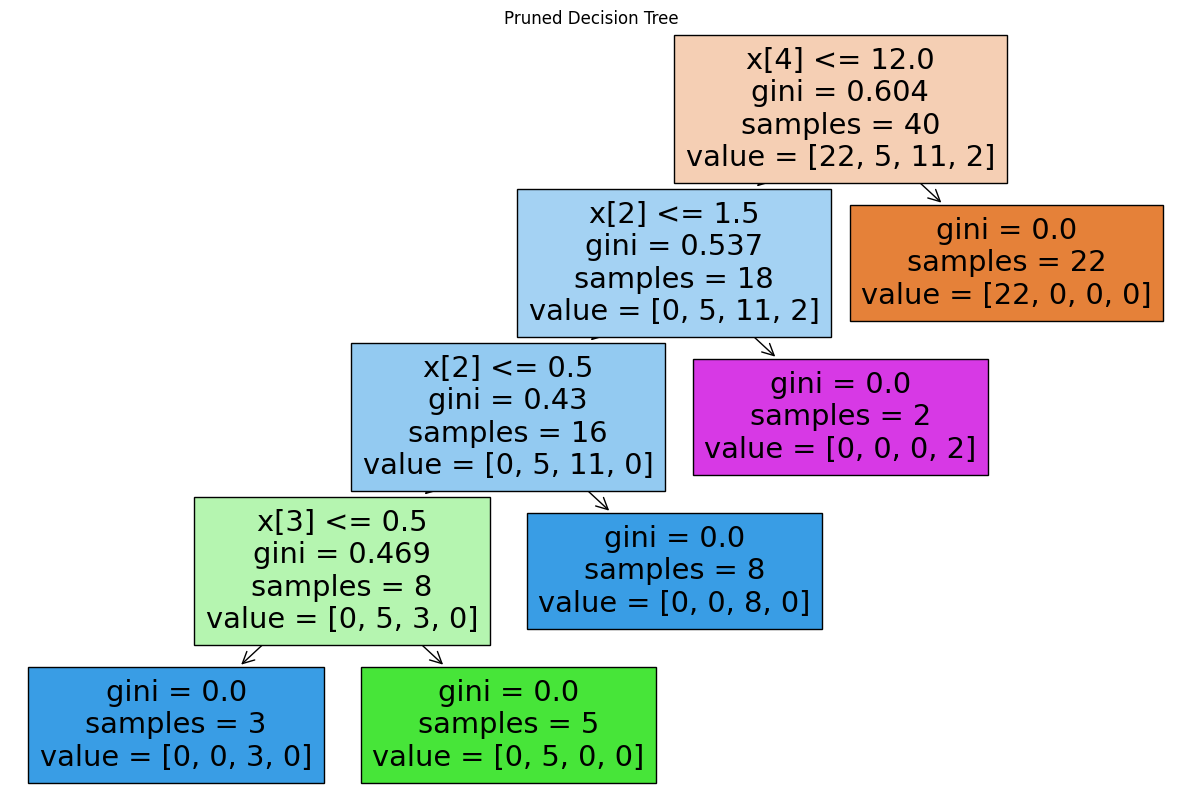

In [35]:
# th Adjusted tree 
plt.figure(figsize=(15, 10))
plot_tree(tree2, filled=True)
plt.title("Pruned Decision Tree")
plt.show()

In [36]:
tree2.score(X_test,y_test)

0.73125

### Splitting

In [37]:
X.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'], dtype='object')

In [38]:
tindex = list(X.columns).index('Na_to_K')
tindex

4

In [39]:
y.unique()

array([0, 1, 2, 3, 4])

Combined tree accuracy: 0.82


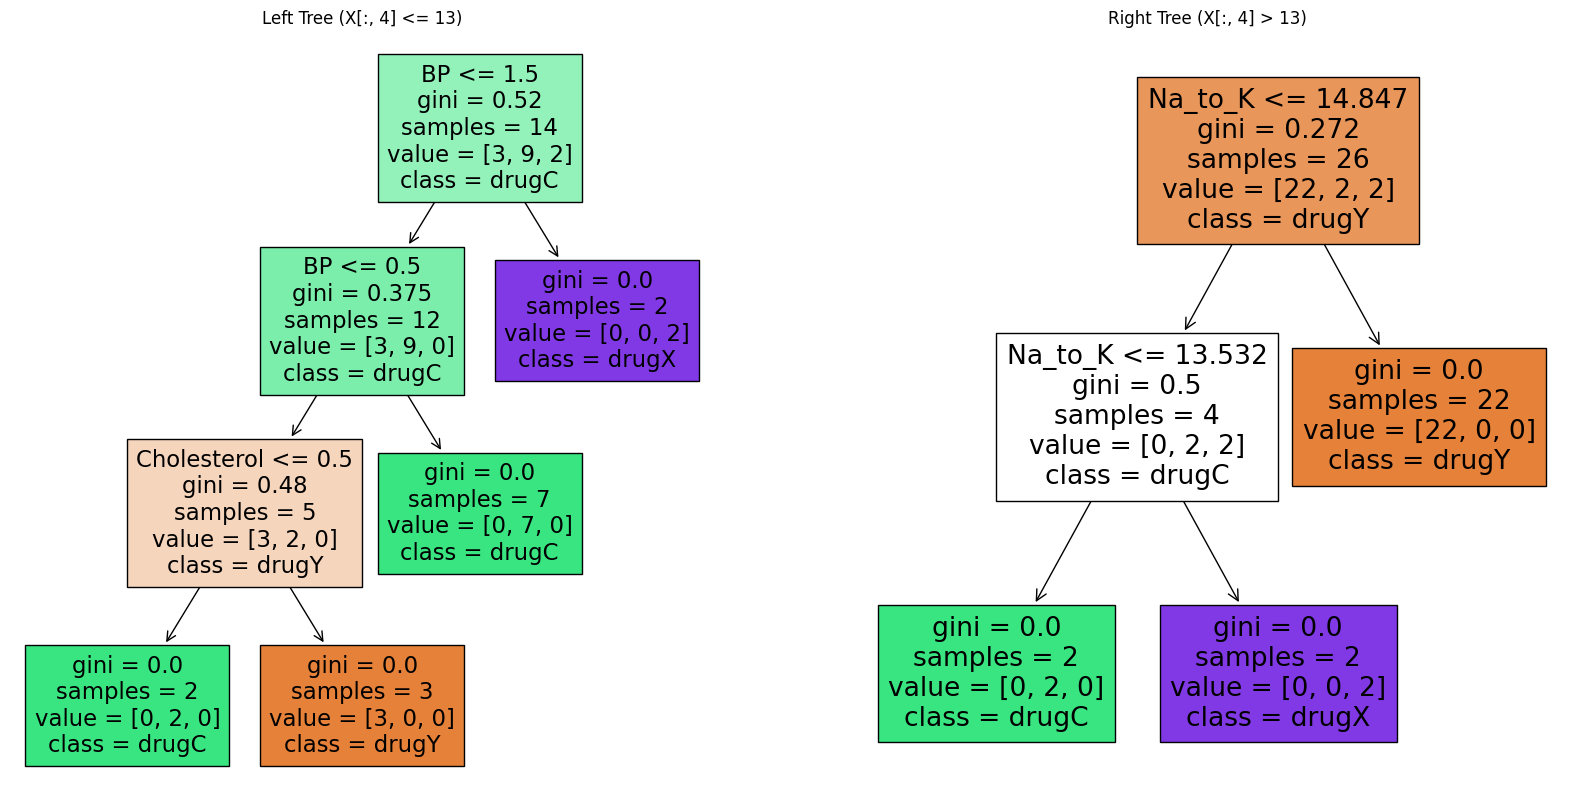

In [40]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)


# Define the custom threshold for the root node split
threshold = 13

# Split the data manually at the root node based on the threshold
left_mask = X_train.iloc[:, tindex] <= threshold  # Splitting based on the first feature (index 0)
right_mask = X_train.iloc[:, tindex] > threshold

# Data for the left and right nodes
X_left, y_left = X_train[left_mask], y_train[left_mask]
X_right, y_right = X_train[right_mask], y_train[right_mask]

# Train separate trees on each subset
clf_left = DecisionTreeClassifier()
clf_left.fit(X_left, y_left)

clf_right = DecisionTreeClassifier()
clf_right.fit(X_right, y_right)

# Combine predictions from the left and right trees
y_pred = np.empty_like(y_test)

# Handle left side of the split
y_pred[X_test.iloc[:, tindex] <= threshold] = clf_left.predict(X_test[X_test.iloc[:, tindex] <= threshold])

# Handle right side of the split
y_pred[X_test.iloc[:, tindex] > threshold] = clf_right.predict(X_test[X_test.iloc[:, tindex] > threshold])

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Combined tree accuracy: {accuracy:.2f}")

# Visualize the trees
plt.figure(figsize=(20, 10))

# Visualize the left tree
plt.subplot(121)
plot_tree(clf_left, filled=True, feature_names=X.columns, class_names=[inv_y_map[i] for i in y.unique()])
plt.title(f"Left Tree (X[:, {tindex}] <= {threshold})")

# Visualize the right tree
plt.subplot(122)
plot_tree(clf_right, filled=True, feature_names=X.columns, class_names=[inv_y_map[i] for i in y.unique()])
plt.title(f"Right Tree (X[:, {tindex}] > {threshold})")

plt.show()

## C4.5

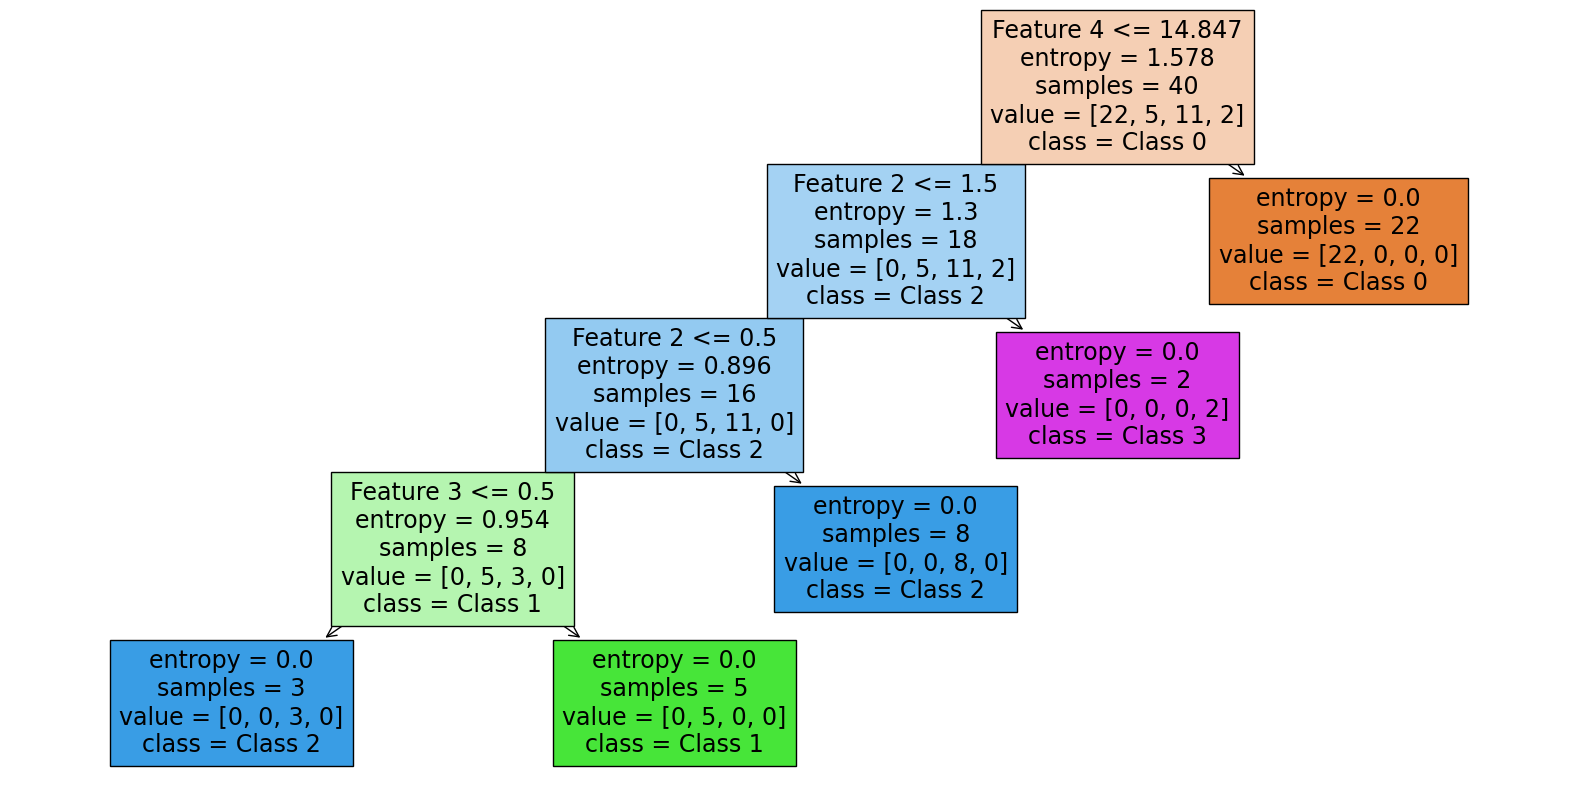

In [41]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt



# Create a decision tree classifier with criterion 'entropy' (C4.5)
clf_c45 = DecisionTreeClassifier(criterion='entropy', splitter='best')
clf_c45.fit(X_train, y_train)

# Visualize the tree
plt.figure(figsize=(20,10))
plot_tree(clf_c45, feature_names=[f'Feature {i}' for i in range(X.shape[1])], class_names=[f'Class {i}' for i in np.unique(y)], filled=True)
plt.show()


In [42]:
clf_c45.score(X_test,y_test)

0.85625

## Chi-Squared Automatic Interaction Detector (CHAID)

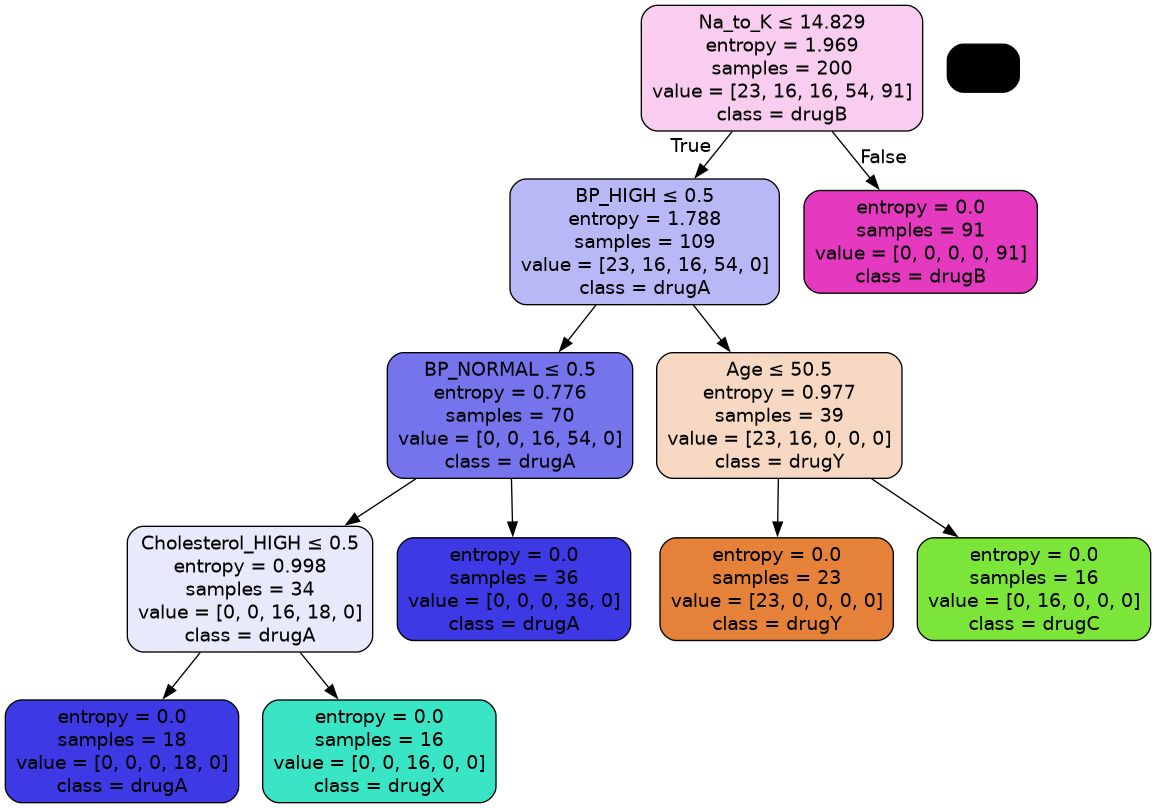

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import chi2

# Load the dataset
df2 = pd.read_csv(paths[0])

# Assuming 'income' is the target variable (you might need to adjust this)
X = df2.drop('Drug', axis=1)
y = df2['Drug']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X)

# Calculate chi-squared statistics for feature selection
chi2_scores, p_values = chi2(X, y)

# Select the most relevant features based on chi-squared scores
# (You might need to adjust the threshold for feature selection)
relevant_features = X.columns[chi2_scores > 1]
X_selected = X[relevant_features]

# Create and fit the decision tree using the selected features
tree = DecisionTreeClassifier(criterion='entropy')  
tree.fit(X_selected, y)

# Visualize the decision tree
dot_data = StringIO()
export_graphviz(tree, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                feature_names=X_selected.columns,
                class_names=y.unique().astype(str))  # Convert class names to strings
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())
